# Domain Enrichment FPR stability

Here, we are showing how FPR values change as we change the number of null model trials used in FPR calculations.

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

In [65]:
# Import the data
fpr_vals = pd.read_csv('260820_Null_p_val_dists_15K_tcga_500_trials.csv', index_col=0)
real_vals = pd.read_csv('TCGA_Fusion_Domain_Enrichment_Results.csv', index_col=1)

# We'll focus on a small subset of domains to show how their FPR values change.
ngramsOI = {'Kinase':'IPR000719', 'Znf-C2H2':'IPR013087', 'EGF':'IPR000742','SH3':'IPR001452','Znf-RING':'IPR001841','PH':'IPR001849'}

fpr_filt = fpr_vals.filter(ngramsOI.values(), axis = 0)
real_filt = real_vals.filter(ngramsOI.values(), axis = 0)

In [66]:
# Now conduct subsetting and calculate a distribution of FPR values based on the subsetted values
subset_size = [10,25,50,75,90,100]
trials = 20
subsetting_records = []
random.seed(123)

for s in subset_size:
    for i in range(trials):
        colsOI = random.sample(fpr_filt.columns.tolist(), k = s)
        x = fpr_filt.filter(colsOI, axis = 1)
        counts = x.lt(real_filt['True_q'], axis=0).sum(axis=1).div(s)
        for ngram, fpr in counts.items():
            subsetting_records.append({
            'ngram': ngram,
            'fpr': fpr,
            'subset_size': s,
            'trial': i
            })

res = pd.DataFrame.from_records(subsetting_records)

In [67]:
res['domain'] = res['ngram'].map({v:k for k,v in ngramsOI.items()})

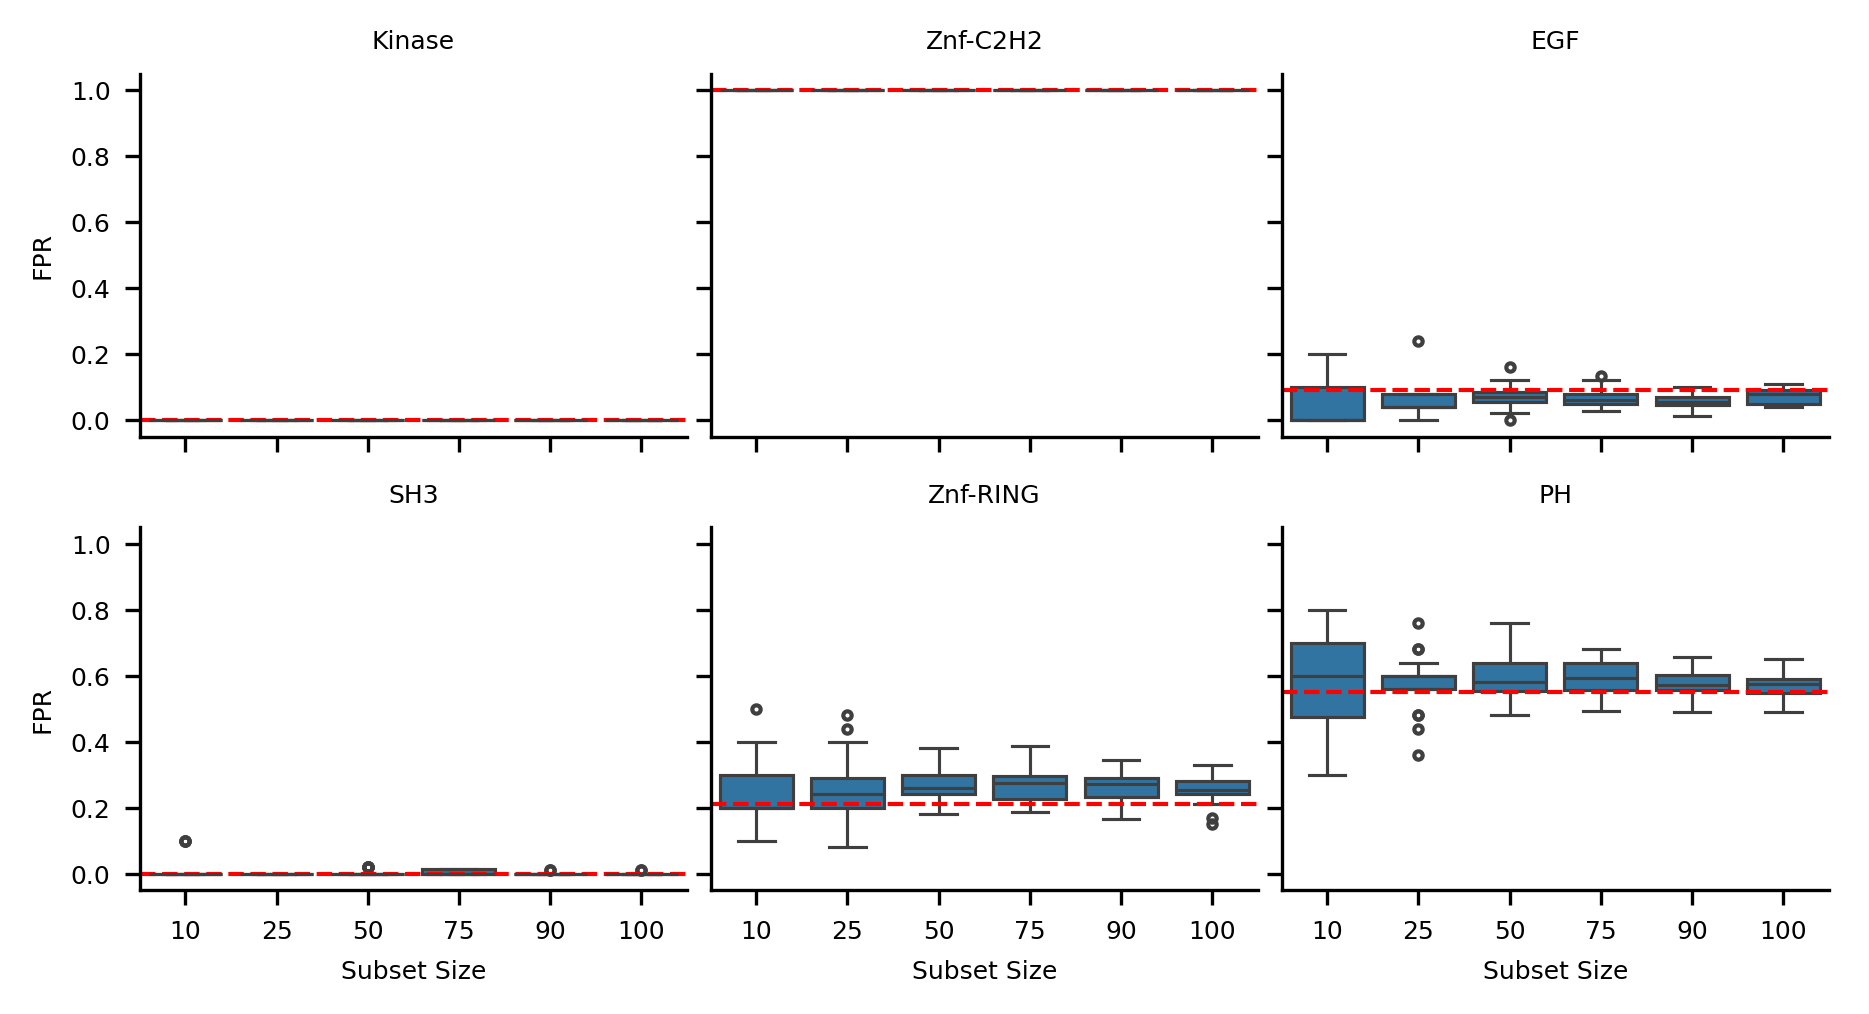

In [80]:
g = sns.catplot(
    data=res,
    col='domain',
    col_wrap=3,
    kind='box',
    x='subset_size',
    y='fpr',
    fliersize = 2,
    linewidth = 0.75
)

for ngram, ax in g.axes_dict.items():
    reference_fpr = real_filt.loc[ngramsOI[ngram], 'fpr']
    ax.axhline(
        reference_fpr,
        color='red',
        linestyle='--',
        linewidth=1,
    )
    ax.tick_params(labelsize=6)

# g.refline(y=0.05, color = 'red', ls = '--', lw = 1)

g.figure.set_dpi(300)
g.figure.set_size_inches(6,3)
g.set_axis_labels(x_var='Subset Size', y_var='FPR',size=6)
g.set_titles(template="{col_name}",size=6)
g.figure.subplots_adjust(hspace=0.25)